In [ ]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the preprocessed data
df_eda = pd.read_csv('df_preprocessed.csv')

In [15]:
# Basic Statistics
print(df_eda.describe())

       Aircraft_Capacity   Passengers  Load_Factor  Flight_Hours  \
count        7974.000000  7974.000000  7974.000000   7974.000000   
mean          317.800602   254.819162     0.801570      6.327314   
std            98.768543    88.141968     0.087755      4.555668   
min           180.000000   104.000000     0.576600      1.200000   
25%           296.000000   180.250000     0.736825      3.200000   
50%           325.000000   246.000000     0.801500      4.500000   
75%           396.000000   302.000000     0.873100      7.500000   
max           517.000000   491.000000     0.950000     16.500000   

       Ticket_Revenue  Ancillary_Revenue  Total_Revenue      Fuel_Cost  \
count    7.974000e+03        7974.000000   7.974000e+03    7974.000000   
mean     2.643839e+05       33052.324090   2.974362e+05   46296.405878   
std      2.371022e+05       30133.939765   2.668329e+05   43123.036900   
min      1.481234e+04        1616.620000   1.665002e+04    2592.620000   
25%      5.642951

Some new features are calculated for EDA/business interpretation

In [16]:
sns.set_theme(style="whitegrid", context="notebook")

# Categorize cost
DIRECT_COSTS = ['Fuel_Cost', 'Maintenance_Cost', 'Crew_Cost', 'Depreciation_Cost', 'Insurance_Cost']
SERVICE_COSTS = ['Airport_Fees', 'Catering_Cost', 'Handling_Cost', 'Navigation_Fees']
INDIRECT_COSTS = ['Sales_Distribution_Cost', 'Passenger_Service_Cost',
                  'Overhead_Cost', 'Marketing_Cost', 'IT_Systems_Cost']
cost_cols = DIRECT_COSTS + SERVICE_COSTS + INDIRECT_COSTS
# Analysis-only features
df_eda['Revenue_Per_Passenger'] = df_eda['Total_Revenue'] / df_eda['Passengers']
df_eda['Cost_Per_Passenger'] = df_eda['Total_Cost'] / df_eda['Passengers']
df_eda['Profit_Per_Passenger'] = df_eda['Profit'] / df_eda['Passengers']

df_eda['Fuel_Pct_Total_Cost'] = df_eda['Fuel_Cost'] / df_eda['Total_Cost'] * 100
df_eda['AirportFees_Pct_Total_Cost'] = df_eda['Airport_Fees'] / df_eda['Total_Cost'] * 100
df_eda['Catering_Pct_Total_Cost'] = df_eda['Catering_Cost'] / df_eda['Total_Cost'] * 100

df_eda['Estimated_Distance_km'] = df_eda['Flight_Hours'] * 850
df_eda['ASK'] = df_eda['Aircraft_Capacity'] * df_eda['Estimated_Distance_km']  # Available Seat Kilometres
df_eda['RPK'] = df_eda['Passengers'] * df_eda['Estimated_Distance_km']         # Revenue Passenger Kilometres
df_eda['CASK'] = df_eda['Total_Cost'] / df_eda['ASK']                          # Cost per ASK
df_eda['RASK'] = df_eda['Total_Revenue'] / df_eda['ASK']                       # Revenue per ASK -> RASK > CASK generally means profitable
df_eda['Yield_per_RPK'] = df_eda['Total_Revenue'] / df_eda['RPK']

df_eda['Is_Profitable'] = (df_eda['Profit'] > 0).astype(int)

# Optional month order for seasonality charts
season_order = ['Peak', 'Shoulder', 'Normal', 'Low']

PALETTE_ROUTE = {
    'Short Haul': '#4C78A8',
    'Medium Haul': '#F58518',
    'Long Haul': '#54A24B'
}

### Key finanical distributions

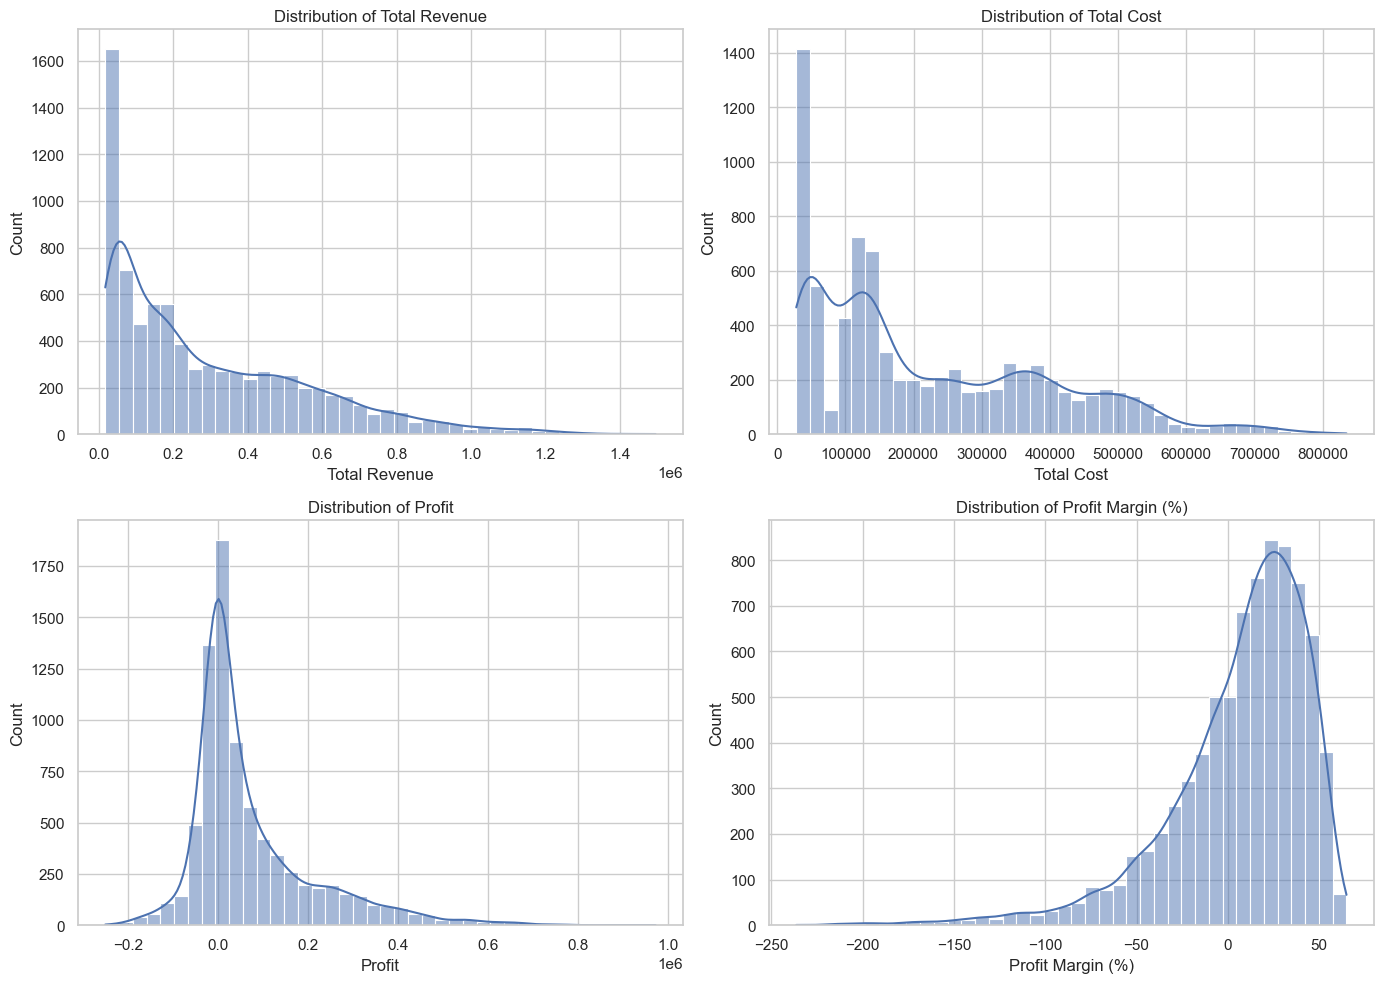

In [17]:
metrics = ['Total_Revenue', 'Total_Cost', 'Profit', 'Profit_Margin']
titles = ['Total Revenue', 'Total Cost', 'Profit', 'Profit Margin (%)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col, title in zip(axes, metrics, titles):
    sns.histplot(df_eda[col], bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution of {title}')
    ax.set_xlabel(title)

plt.tight_layout()
plt.show()

Profit is concentrated around zero, but still right-skewed, suggesting that many flights earn only modest profit while a smaller group generates very large gains. A subset of flights is deeply loss-making even though the overall distribution is centered in positive territory

#### Top Destinations

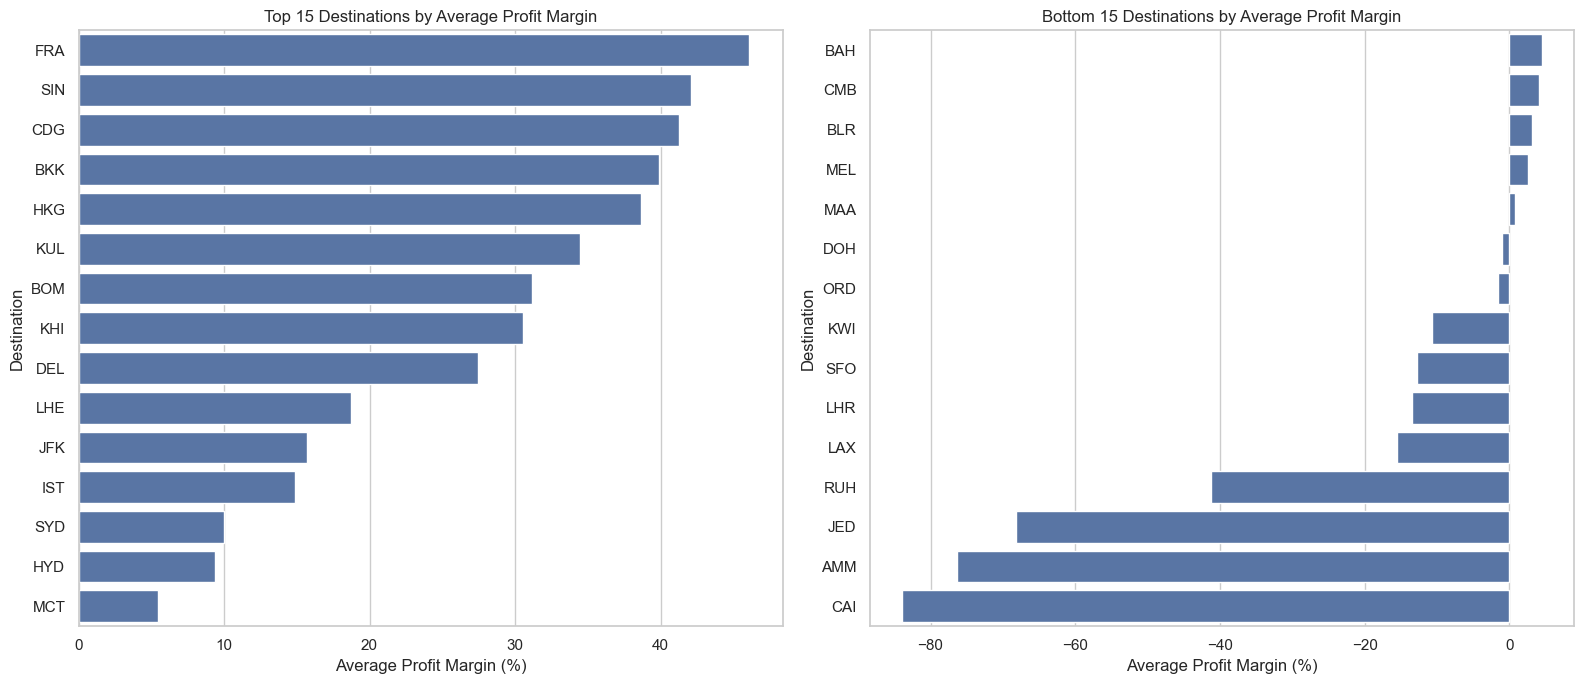

In [18]:
top_dest_margin = (
    df_eda.groupby('Destination')
    .agg(
        Avg_Profit_Margin=('Profit_Margin', 'mean'),
        Avg_Profit=('Profit', 'mean'),
        Avg_Revenue=('Total_Revenue', 'mean'),
        Flights=('Flight_Number', 'count')
    )
    .sort_values('Avg_Profit_Margin', ascending=False)
)

top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=top_dest_margin.head(top_n).reset_index(),
    y='Destination', x='Avg_Profit_Margin', ax=axes[0]
)
axes[0].set_title(f'Top {top_n} Destinations by Average Profit Margin')
axes[0].set_xlabel('Average Profit Margin (%)')
axes[0].set_ylabel('Destination')

sns.barplot(
    data=top_dest_margin.tail(top_n).reset_index(),
    y='Destination', x='Avg_Profit_Margin', ax=axes[1]
)
axes[1].set_title(f'Bottom {top_n} Destinations by Average Profit Margin')
axes[1].set_xlabel('Average Profit Margin (%)')
axes[1].set_ylabel('Destination')

plt.tight_layout()
plt.show()

At the destination level, profitability is highly uneven. This suggests that network profitability depends heavily on route economics rather than simply traffic volume.

#### Aircraft type & route category performance

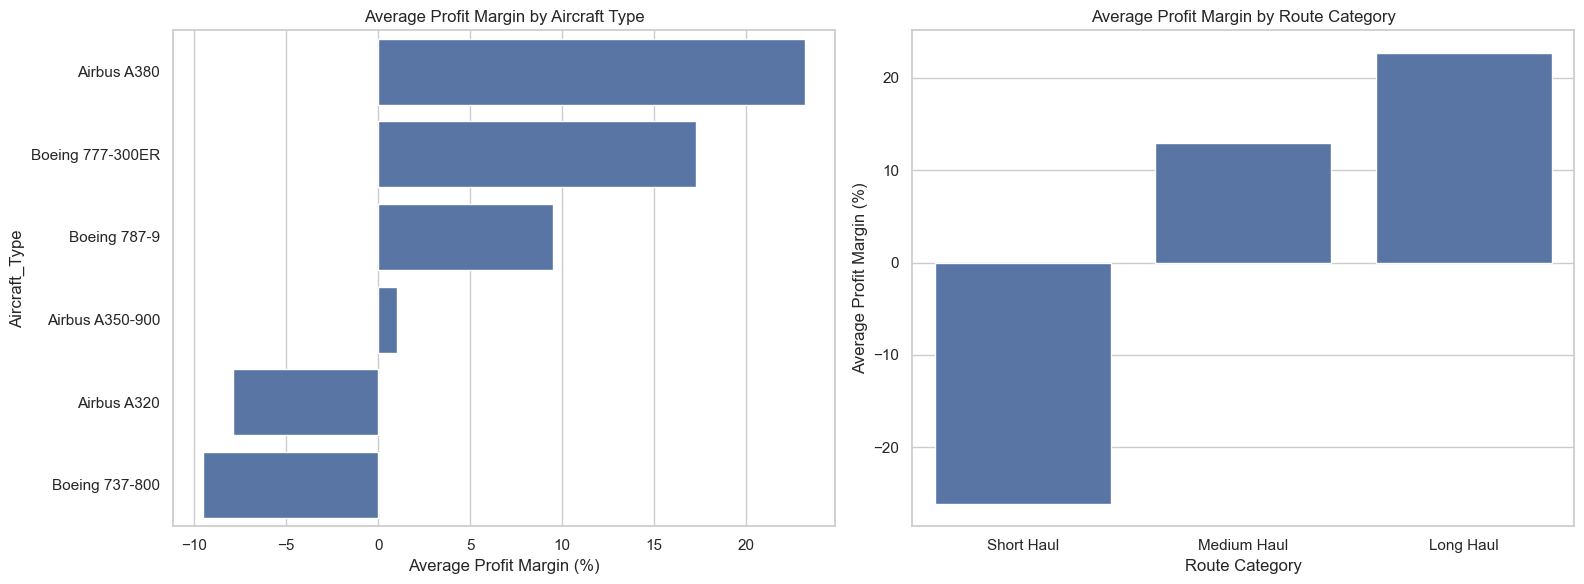

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

aircraft_perf = (
    df_eda.groupby('Aircraft_Type')
    .agg(
        Avg_Profit_Margin=('Profit_Margin', 'mean'),
        Avg_Profit=('Profit', 'mean')
    )
    .sort_values('Avg_Profit_Margin', ascending=False)
    .reset_index()
)

sns.barplot(data=aircraft_perf, x='Avg_Profit_Margin', y='Aircraft_Type', ax=axes[0])
axes[0].set_title('Average Profit Margin by Aircraft Type')
axes[0].set_xlabel('Average Profit Margin (%)')

route_perf = (
    df_eda.groupby('Route_Category')
    .agg(
        Avg_Profit_Margin=('Profit_Margin', 'mean'),
        Avg_Profit=('Profit', 'mean'),
        Avg_Revenue=('Total_Revenue', 'mean'),
        Avg_Cost=('Total_Cost', 'mean')
    )
    .reset_index()
)

sns.barplot(
    data=route_perf,
    x='Route_Category', y='Avg_Profit_Margin',
    order=['Short Haul', 'Medium Haul', 'Long Haul'],
    ax=axes[1]
)
axes[1].set_title('Average Profit Margin by Route Category')
axes[1].set_xlabel('Route Category')
axes[1].set_ylabel('Average Profit Margin (%)')

plt.tight_layout()
plt.show()

By aircraft type, larger long-haul widebody aircraft appear to perform better on average. While the Boeing 737-800 and Airbus A320 are associated with negative average margins.

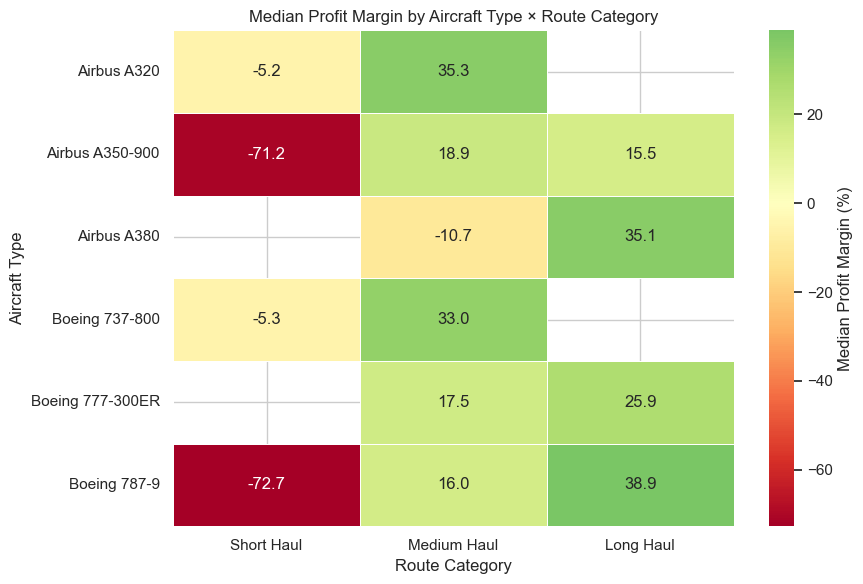

In [20]:
pivot_aircraft_route = df_eda.pivot_table(
    index='Aircraft_Type',
    columns='Route_Category',
    values='Profit_Margin',
    aggfunc='median'
)

route_order = ['Short Haul', 'Medium Haul', 'Long Haul']
pivot_aircraft_route = pivot_aircraft_route.reindex(columns=route_order)

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot_aircraft_route,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    cbar_kws={'label': 'Median Profit Margin (%)'}
)
plt.title('Median Profit Margin by Aircraft Type × Route Category')
plt.xlabel('Route Category')
plt.ylabel('Aircraft Type')
plt.tight_layout()
plt.show()

Clearly short-haul flights are structurally weaker, whereas medium-haul and especially long-haul routes are more profitable on average.

Some aircraft perform very poorly on short-haul routes but very well on medium- or long-haul routes. This suggests that same fleet type can generate very different financial outcomes depending on deployment.

#### Cost Structure

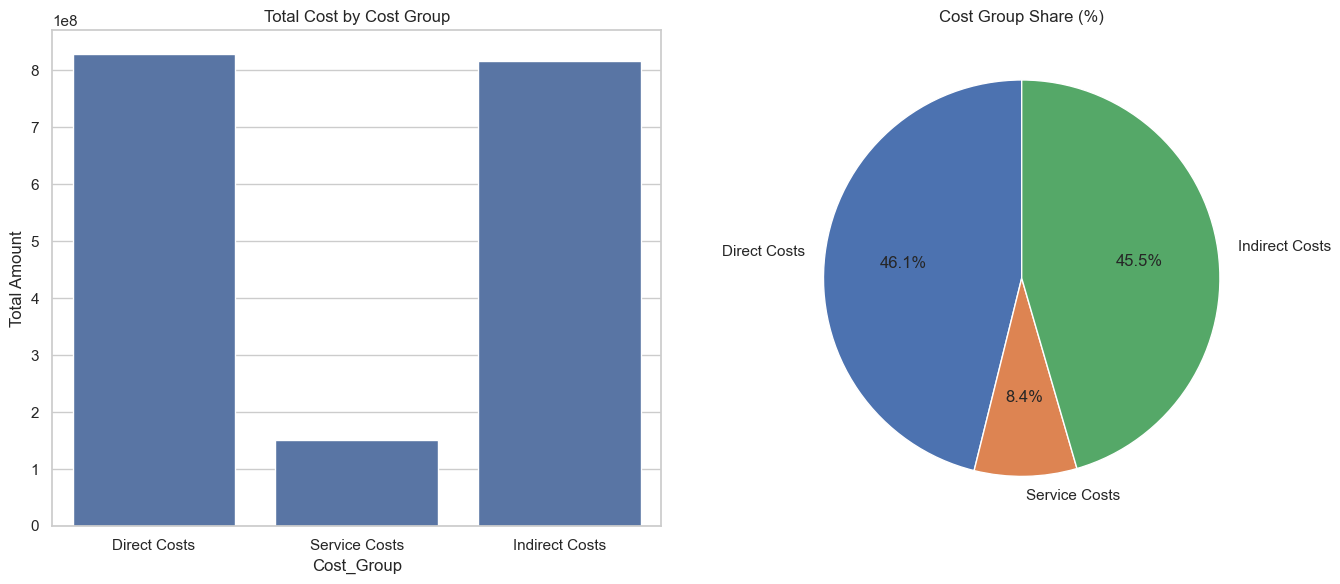

In [21]:
cost_group_summary = pd.DataFrame({
    'Direct Costs': [df_eda[DIRECT_COSTS].sum().sum()],
    'Service Costs': [df_eda[SERVICE_COSTS].sum().sum()],
    'Indirect Costs': [df_eda[INDIRECT_COSTS].sum().sum()]
}).T.reset_index()

cost_group_summary.columns = ['Cost_Group', 'Total_Amount']
cost_group_summary['Share_Pct'] = cost_group_summary['Total_Amount'] / cost_group_summary['Total_Amount'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=cost_group_summary, x='Cost_Group', y='Total_Amount', ax=axes[0])
axes[0].set_title('Total Cost by Cost Group')
axes[0].set_ylabel('Total Amount')

axes[1].pie(
    cost_group_summary['Share_Pct'],
    labels=cost_group_summary['Cost_Group'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Cost Group Share (%)')

plt.tight_layout()
plt.show()

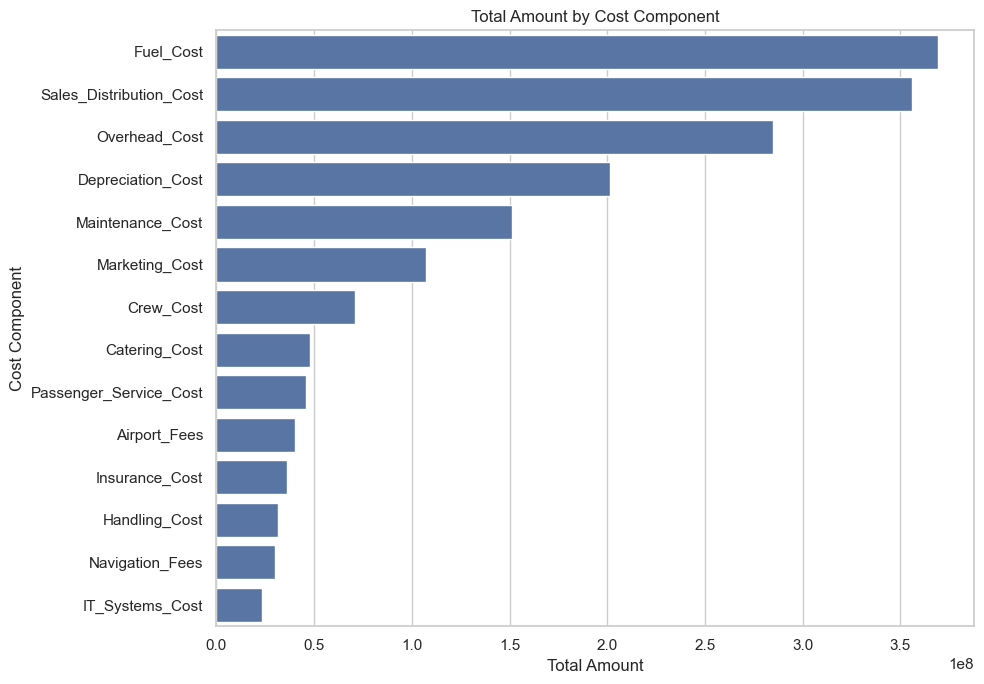

In [22]:
cost_component_totals = df_eda[cost_cols].sum().sort_values(ascending=False).reset_index()
cost_component_totals.columns = ['Cost_Component', 'Total_Amount']

plt.figure(figsize=(10, 7))
sns.barplot(data=cost_component_totals, y='Cost_Component', x='Total_Amount')
plt.title('Total Amount by Cost Component')
plt.xlabel('Total Amount')
plt.ylabel('Cost Component')
plt.tight_layout()
plt.show()

At the component level, Fuel_Cost is the largest single cost item, followed closely by Sales_Distribution_Cost and Overhead_Cost. This indicates that both operational efficiency and commercial cost control are central to route profitability.

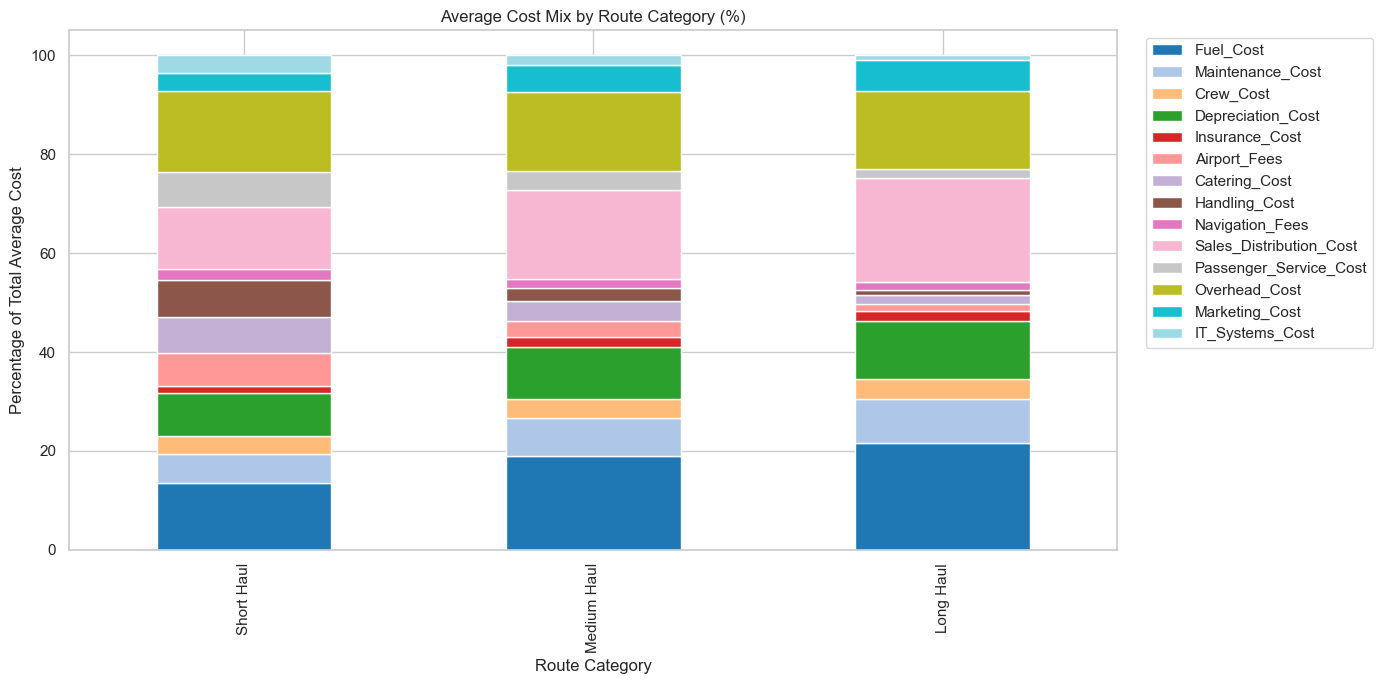

In [23]:
route_cost_mix = (
    df_eda.groupby('Route_Category')[cost_cols]
    .mean()
)

route_cost_mix_pct = route_cost_mix.div(route_cost_mix.sum(axis=1), axis=0) * 100

route_cost_mix_pct.loc[['Short Haul', 'Medium Haul', 'Long Haul']].plot(
    kind='bar', stacked=True, figsize=(14, 7), colormap='tab20'
)
plt.title('Average Cost Mix by Route Category (%)')
plt.xlabel('Route Category')
plt.ylabel('Percentage of Total Average Cost')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

The cost mix differs visibly by route category. Long-haul flights carry a higher share of fuel, maintenance, and depreciation costs, which is consistent with longer sector lengths and heavier aircraft utilization.

Short-haul routes show relatively higher shares of airport, catering, handling, and passenger-service costs, meaning fixed or semi-fixed turnaround-related costs weigh more heavily on shorter sectors. This helps explain why their profitability is structurally weaker: their revenue base is lower while several service-related costs remain proportionally burdensome.

#### Operational efficiency (generally RASK > CASK means profitable)

NameError: name 'Patch' is not defined

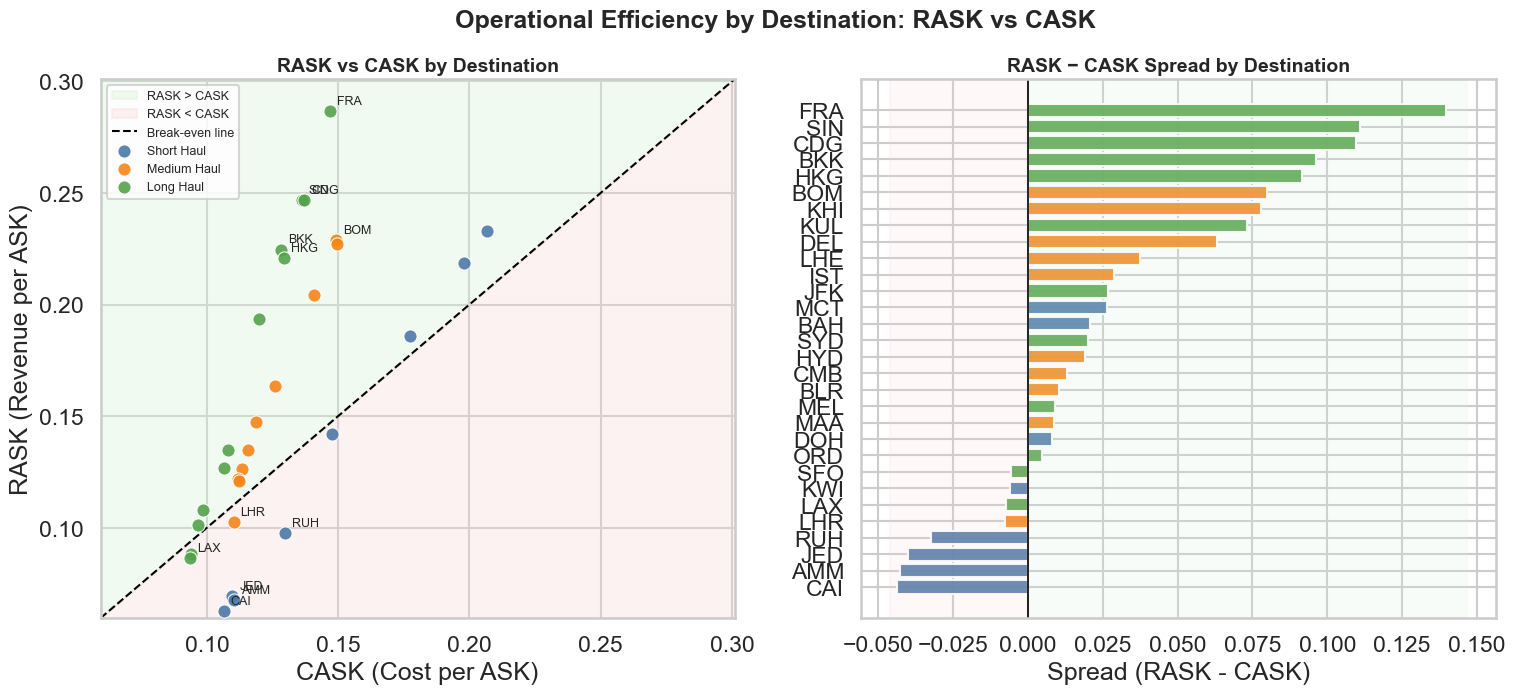

In [24]:
sns.set_theme(style="whitegrid", context="talk")

cask_rask = (
    df_eda.groupby('Destination')
    .agg(
        CASK=('CASK', 'mean'),
        RASK=('RASK', 'mean'),
        Route_Category=('Route_Category', 'first'),
        Profit_Margin=('Profit_Margin', 'mean')
    )
    .reset_index()
)

cask_rask['Spread'] = cask_rask['RASK'] - cask_rask['CASK']
cask_rask = cask_rask.sort_values('Spread', ascending=False)

# Select only a subset of destinations to annotate on scatter
label_points = pd.concat([
    cask_rask.head(6),   # best spread
    cask_rask.tail(6)    # worst spread
]).drop_duplicates()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Operational Efficiency by Destination: RASK vs CASK', fontsize=18, fontweight='bold')

# -----------------------------
# Left panel: Scatter plot
# -----------------------------
ax = axes[0]

min_val = min(cask_rask['CASK'].min(), cask_rask['RASK'].min()) * 0.95
max_val = max(cask_rask['CASK'].max(), cask_rask['RASK'].max()) * 1.05

# Soft background zones
ax.fill_between([min_val, max_val], [min_val, max_val], max_val,
                color='#D9F2D9', alpha=0.35, label='RASK > CASK')
ax.fill_between([min_val, max_val], min_val, [min_val, max_val],
                color='#F9D6D5', alpha=0.30, label='RASK < CASK')

# Break-even line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle='--', color='black', linewidth=1.5, label='Break-even line')

# Scatter points by route category
for cat, color in PALETTE_ROUTE.items():
    subset = cask_rask[cask_rask['Route_Category'] == cat]
    ax.scatter(
        subset['CASK'],
        subset['RASK'],
        s=90,
        color=color,
        edgecolor='white',
        linewidth=0.8,
        alpha=0.9,
        label=cat,
        zorder=3
    )

# Annotate only selected routes
for _, row in label_points.iterrows():
    ax.annotate(
        row['Destination'],
        (row['CASK'], row['RASK']),
        textcoords='offset points',
        xytext=(5, 5),
        fontsize=9,
        fontweight='medium'
    )

ax.set_title('RASK vs CASK by Destination', fontsize=14, fontweight='bold')
ax.set_xlabel('CASK (Cost per ASK)')
ax.set_ylabel('RASK (Revenue per ASK)')
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
seen = set()
unique_handles_labels = []
for h, l in zip(handles, labels):
    if l not in seen:
        unique_handles_labels.append((h, l))
        seen.add(l)
ax.legend(
    [h for h, _ in unique_handles_labels],
    [l for _, l in unique_handles_labels],
    fontsize=9,
    loc='upper left',
    frameon=True
)

# -----------------------------
# Right panel: Spread bar chart
# -----------------------------
ax = axes[1]

bar_colors = [PALETTE_ROUTE[c] for c in cask_rask['Route_Category']]
bars = ax.barh(
    cask_rask['Destination'],
    cask_rask['Spread'],
    color=bar_colors,
    edgecolor='white',
    alpha=0.95
)

# Reference line
ax.axvline(0, color='black', linewidth=1.2)

# Optional highlight for positive vs negative zone
ax.axvspan(0, cask_rask['Spread'].max() * 1.05, color='#D9F2D9', alpha=0.18)
ax.axvspan(cask_rask['Spread'].min() * 1.05, 0, color='#F9D6D5', alpha=0.16)

ax.set_title('RASK − CASK Spread by Destination', fontsize=14, fontweight='bold')
ax.set_xlabel('Spread (RASK - CASK)')
ax.set_ylabel('')
ax.invert_yaxis()

legend_elements = [Patch(facecolor=v, label=k) for k, v in PALETTE_ROUTE.items()]
ax.legend(handles=legend_elements, title='Route Category', fontsize=9, title_fontsize=10, frameon=True)

# Light clean-up
for a in axes:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Many long-haul routes sit well above the break-even line, indicating that their revenue generation more than offsets their higher cost intensity.

#### Seasonality

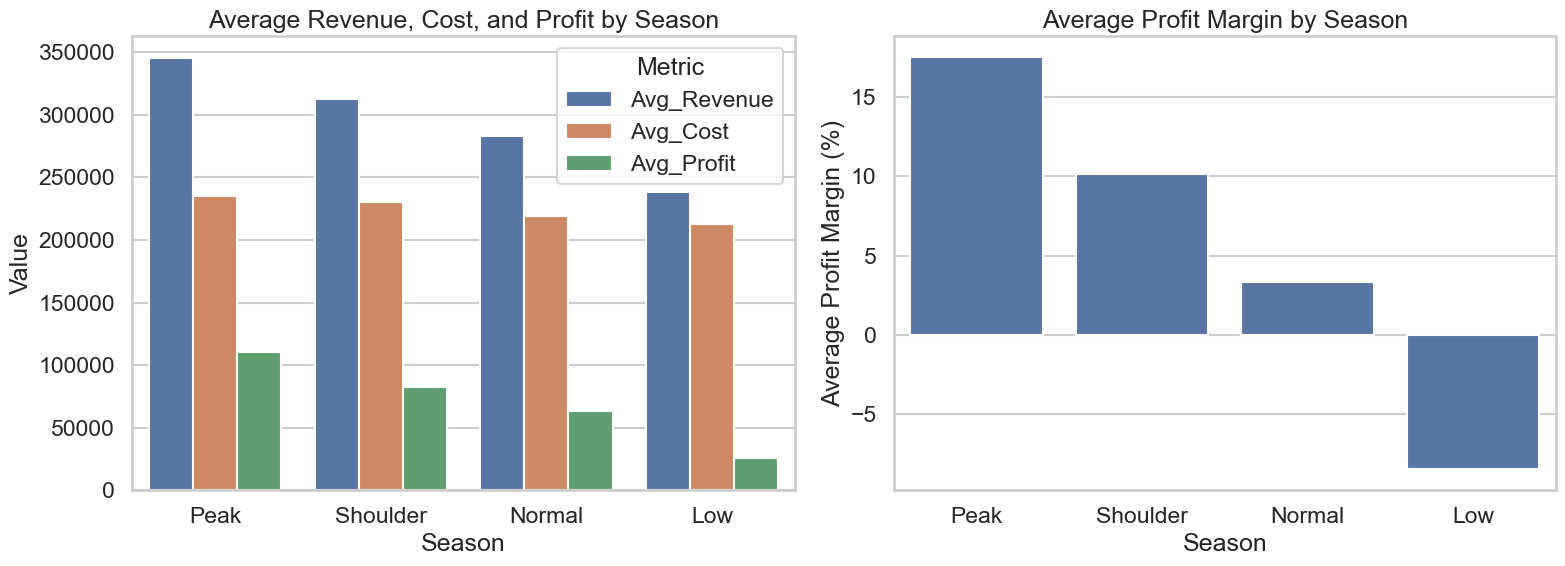

In [25]:
season_summary = (
    df_eda.groupby('Season')
    .agg(
        Avg_Revenue=('Total_Revenue', 'mean'),
        Avg_Cost=('Total_Cost', 'mean'),
        Avg_Profit=('Profit', 'mean'),
        Avg_Profit_Margin=('Profit_Margin', 'mean')
    )
    .reindex(season_order)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

season_summary_melt = season_summary.melt(
    id_vars='Season',
    value_vars=['Avg_Revenue', 'Avg_Cost', 'Avg_Profit'],
    var_name='Metric',
    value_name='Value'
)

sns.barplot(data=season_summary_melt, x='Season', y='Value', hue='Metric', ax=axes[0])
axes[0].set_title('Average Revenue, Cost, and Profit by Season')

sns.barplot(data=season_summary, x='Season', y='Avg_Profit_Margin', ax=axes[1])
axes[1].set_title('Average Profit Margin by Season')
axes[1].set_ylabel('Average Profit Margin (%)')

plt.tight_layout()
plt.show()

Peak season delivers the highest average revenue, profit, and profit margin, while profitability deteriorates steadily through Shoulder and Normal seasons and turns negative in Low season.

Average cost changes much less across seasons than revenue, which suggests that margin compression in low season is driven more by weaker revenue than by falling costs.